
Best parameters: k=91, bw=0.23 with accuracy 0.9620


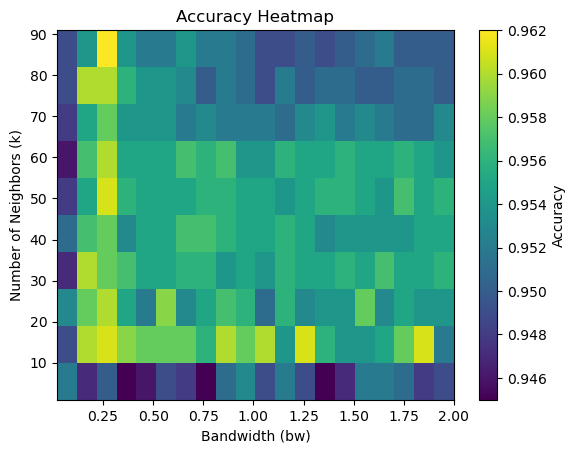

In [ ]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

N_SAMPLES = 1000

# Generate synthetic dataset
X, y = make_classification(
  n_samples=N_SAMPLES,
  n_features=2,
  n_classes=2,
  n_informative=2,
  n_redundant=0,
  n_repeated=0,
  random_state=0
)

kf = KFold(n_splits=10, shuffle=True, random_state=0)

# Define ranges for k and bandwidth (bw)
ks = range(1, max(N_SAMPLES // 10, 1), max(N_SAMPLES // 100, 1))
bws = np.linspace(0.02, 2, 20)

results = []

for k in ks:
  for bw in bws:

    # Gaussian kernel weighted KNN
    clf = KNeighborsClassifier(
    n_neighbors=k,
    weights=lambda d: np.exp(-d**2 / (2 * bw**2))  # Gaussian kernel
    )

    accuracies = cross_val_score(clf, X, y, cv=kf, scoring='accuracy', n_jobs=-1)
    
    mean_accuracy = np.mean(accuracies)
    results.append((k, bw, mean_accuracy))


best_k, best_bw, best_acc = max(results, key=lambda x: x[2])
print(f"\nBest parameters: k={best_k}, bw={best_bw:.2f} with accuracy {best_acc:.4f}")

import matplotlib.pyplot as plt

# Extract k, bw, and accuracy values
k_values = sorted(set(k for k, _, _ in results))
bw_values = sorted(set(bw for _, bw, _ in results))

# Create a matrix to store accuracy values
accuracy_matrix = np.zeros((len(k_values), len(bw_values)))

# Fill the matrix with accuracy values
for k, bw, acc in results:
  k_idx = k_values.index(k)
  bw_idx = bw_values.index(bw)
  accuracy_matrix[k_idx, bw_idx] = acc

# Plot the matrix
plt.figure()
plt.imshow(accuracy_matrix, aspect='auto', origin='lower', 
       extent=[min(bw_values), max(bw_values), min(k_values), max(k_values)])
plt.colorbar(label='Accuracy')
plt.xlabel('Bandwidth (bw)')
plt.ylabel('Number of Neighbors (k)')
plt.title('Accuracy Heatmap')
plt.show()
